# Objetivo 3: Diseñar y entrenar modelos predictivos (Redes Neuronales)

Entrenaremos un Perceptrón Multicapa (MLP) estandarizando primero las variables.

# 6. Modelado con Redes Neuronales (MLP) y Exportación

En este notebook validaremos el uso de un Perceptrón Multicapa (MLP) como modelo predictivo de riesgo de rezago escolar, respondiendo así a los objetivos específicos del diplomado.

In [1]:
import pandas as pd
import numpy as np

# Cargar dataset
dataset = pd.read_csv("../data/03_Datasets_Procesados/primaria_dataset.csv")

# Ordenar por rude y gestion para garantizar la secuencia temporal
dataset = dataset.sort_values(["rude", "gestion"])
dataset.reset_index(drop=True, inplace=True)


In [2]:
# Crear variables del año anterior (prev)
features_base = [
    "promedio_general",
    "num_materias_reprobadas"
]

for col in features_base:
    dataset[f"{col}_prev"] = dataset.groupby("rude")[col].shift(1)

# Variable de riesgo a predecir (rezago futuro)
dataset["rezago_next"] = dataset.groupby("rude")["rezago"].shift(-1)

# Eliminar nulos generados por los shifts
model_data = dataset.dropna(subset=[
    "promedio_general_prev", 
    "num_materias_reprobadas_prev", 
    "rezago_next"
])


In [3]:
# Seleccionar Features (X) y Target (y)
features = [
    "promedio_general_prev",
    "num_materias_reprobadas_prev"
]

X = model_data[features]
y = model_data["rezago_next"]


In [4]:
# Separación en conjunto de entrenamiento y de prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


## Estandarización de Datos

Las Redes Neuronales son muy sensibles a la escala de las características. Primero aplicaremos un `StandardScaler`.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Entrenamiento de la Red Neuronal (MLP)

In [6]:
from sklearn.neural_network import MLPClassifier

# Arquitectura simple: 2 capas ocultas de 10 neuronas cada una
mlp = MLPClassifier(
    hidden_layer_sizes=(10, 10), 
    activation="relu", 
    solver="adam", 
    max_iter=500, 
    random_state=42
)

mlp.fit(X_train_scaled, y_train)


/Users/danielcanqui/.pyenv/versions/3.12.0/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/danielcanqui/.pyenv/versions/3.12.0/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/danielcanqui/.pyenv/versions/3.12.0/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


## Evaluación del Modelo

Reporte de Clasificación (MLP):
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99        50
         1.0       0.00      0.00      0.00         1

    accuracy                           0.98        51
   macro avg       0.49      0.50      0.50        51
weighted avg       0.96      0.98      0.97        51



/Users/danielcanqui/.pyenv/versions/3.12.0/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/danielcanqui/.pyenv/versions/3.12.0/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/danielcanqui/.pyenv/versions/3.12.0/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/danielcanqui/.pyenv/versions/3.12.0/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/danielcanqui/.pyenv/versions/3.12.0/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision 

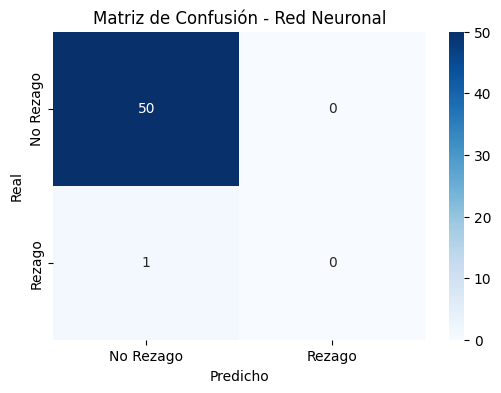

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_mlp = mlp.predict(X_test_scaled)

print("Reporte de Clasificación (MLP):")
print(classification_report(y_test, y_pred_mlp))

cm = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Rezago', 'Rezago'], 
            yticklabels=['No Rezago', 'Rezago'])
plt.title('Matriz de Confusión - Red Neuronal')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()


## Comparación con Random Forest (Baseline Fuerte)

Volvemos a entrenar el Random Forest del notebook anterior para compararlo.

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Reporte de Clasificación (Random Forest Balanceado):")
print(classification_report(y_test, y_pred_rf))


Reporte de Clasificación (Random Forest Balanceado):
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98        50
         1.0       0.00      0.00      0.00         1

    accuracy                           0.96        51
   macro avg       0.49      0.49      0.49        51
weighted avg       0.96      0.96      0.96        51



## Exportación de Modelos para el Dashboard

Exportaremos el Random Forest (dado que maneja muy bien el desbalance de clases usando `class_weight`) y un agrupamiento (scaler) si fuera necesario usar la Red Neuronal más adelante. Esto será consumido por la aplicación de Streamlit integrando el prototipo de apoyo a la decisión docente.

In [9]:
import joblib
import os

# Crear directorio si no existe
os.makedirs("../modelos_entrenados", exist_ok=True)

# Exportar modelo y scaler
joblib.dump(rf, "../modelos_entrenados/random_forest_model.pkl")
joblib.dump(mlp, "../modelos_entrenados/mlp_model.pkl")
joblib.dump(scaler, "../modelos_entrenados/scaler.pkl")

print("Modelos exportados correctamente a la carpeta 'modelos_entrenados/'")


Modelos exportados correctamente a la carpeta 'models/'
